### U-Net + Dice + BCE

In [5]:
# Dataset Objects
from datasets.dataset import ImageMaskDataset

# cldice objects (https://github.com/jocpae/clDice)
from cldice.cldice import soft_cldice
from cldice.soft_skeleton import SoftSkeletonize

# U-Net model and dice loss functions (https://github.com/milesial/Pytorch-UNet)
from unet.dice_score import dice_loss, dice_coefficient
from unet import UNet

# Neural Network Objects
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset


import os
from typing import Optional
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

ModuleNotFoundError: No module named 'datasets.dataset'

**Weighted Loss Functions**

In [ ]:
def combined_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
    bce: nn.Module,
    w_dice: float = 0.5,
    w_bce: float = 0,
) -> torch.Tensor:
    bce_v = bce(logits, targets)
    probs = torch.sigmoid(logits)
    dice = dice_loss(
        probs.squeeze(1),
        targets.squeeze(1).float(),
        multiclass=False,
    )
    loss = w_dice * dice + w_bce * bce_v
    return loss

**Epoch Function**

In [ ]:
def run_epoch(model, loader, device, bce, optimizer, w_dice, w_bce, train, desc=None):
    if train: model.train()
    else: model.eval()

    total_loss = 0.0
    total_dice = 0.0
    n_batches = 0

    it = loader if desc is None else tqdm(loader, desc=desc)
    for images, masks in it:
        images = images.to(device)
        masks = masks.to(device)

        if train:
            assert optimizer is not None
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = combined_loss(logits, masks, bce, w_dice, w_bce)
            loss.backward()
            optimizer.step()

        else:
            with torch.no_grad():
                logits = model(images)
                loss = combined_loss(logits, masks, bce, w_dice, w_bce)

        total_loss += float(loss.item())
        total_dice += dice_coefficient(torch.sigmoid(logits), masks)
        n_batches += 1

    avg_loss = total_loss / n_batches
    avg_dice = total_dice / n_batches
    return avg_loss, avg_dice

**Visualization Function**

In [ ]:
@torch.no_grad()
def visualize_prediction(
    model: nn.Module,
    dataset: Dataset,
    device: torch.device,
    index: int = 0,
    threshold: float = 0.5,
    save_path: Optional[str] = None,
) -> None:
    """Plot image, ground truth mask, and predicted mask for one sample."""
    if index < 0 or index >= len(dataset):
        raise IndexError(f"index {index} is out of range for dataset length {len(dataset)}")

    model.eval()
    image, gt_mask = dataset[index]
    logits = model(image.unsqueeze(0).to(device))
    pred_probs = torch.sigmoid(logits).squeeze(0).squeeze(0).cpu().numpy()
    pred_mask = (pred_probs >= threshold).astype(np.float32)

    image_np = image.permute(1, 2, 0).cpu().numpy()
    gt_mask_np = gt_mask.squeeze(0).cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image_np)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(gt_mask_np, cmap="gray")
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(pred_mask, cmap="gray")
    axes[2].set_title(f"Prediction (thr={threshold:.2f})")
    axes[2].axis("off")

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved visualization to {save_path}")
    else:
        plt.show()
    plt.close(fig)

**Hyperparameters**

In [ ]:
SEED = 42
EPOCHS = 200
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
TRAIN_RATIO = 0.8
DICE_WEIGHT = 1.0
BCE_WEIGHT = 0.0

BILINEAR = False  # True = bilinear upsampling; False = transposed convs (old CLI default)
MODEL_NAME = "unet_baseline.pt"

CROP_SIZE = 512
VIZ_INDEX = 0
VIZ_COUNT = 3
VIZ_THRESHOLD = 0.5
VIZ_SAVE_DIR = "results"
VIZ_PREFIX = "prediction"

**Training Process**

train 1/200: 100%|██████████| 3/3 [00:04<00:00,  1.34s/it]


epoch 1/200  train_loss=0.8132  train_dice=0.1868


train 2/200: 100%|██████████| 3/3 [00:03<00:00,  1.32s/it]


epoch 2/200  train_loss=0.7920  train_dice=0.2080


train 3/200: 100%|██████████| 3/3 [00:04<00:00,  1.44s/it]


...

epoch 199/200  train_loss=0.2208  train_dice=0.7792


train 200/200: 100%|██████████| 3/3 [00:05<00:00,  1.67s/it]


epoch 200/200  train_loss=0.2127  train_dice=0.7873


test: 100%|██████████| 6/6 [00:01<00:00,  4.99it/s]


test_loss=0.2526  test_dice=0.7474
Saved model to /workspace/notebook/models/unet_baseline.pt


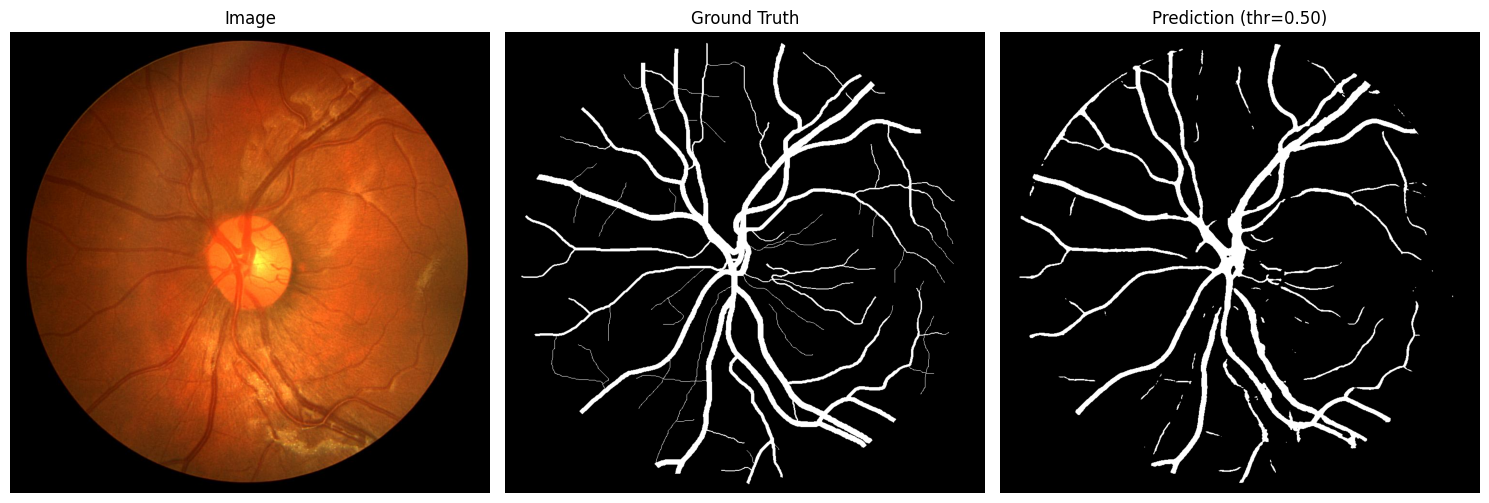

Saved visualization to /workspace/notebook/results/prediction_0.png


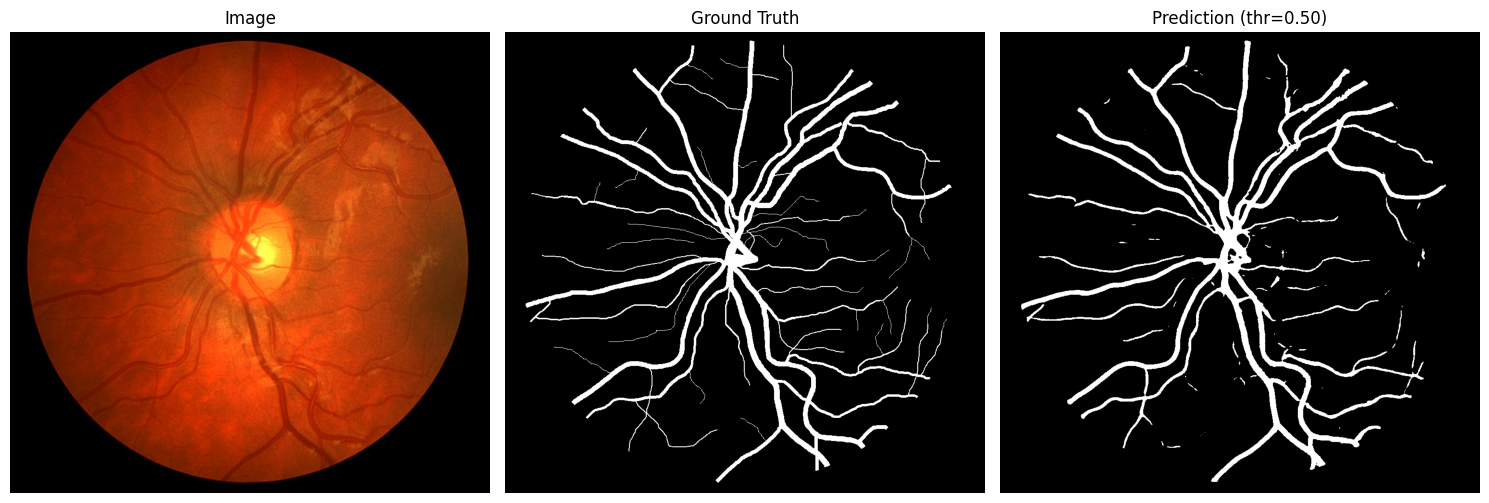

Saved visualization to /workspace/notebook/results/prediction_1.png


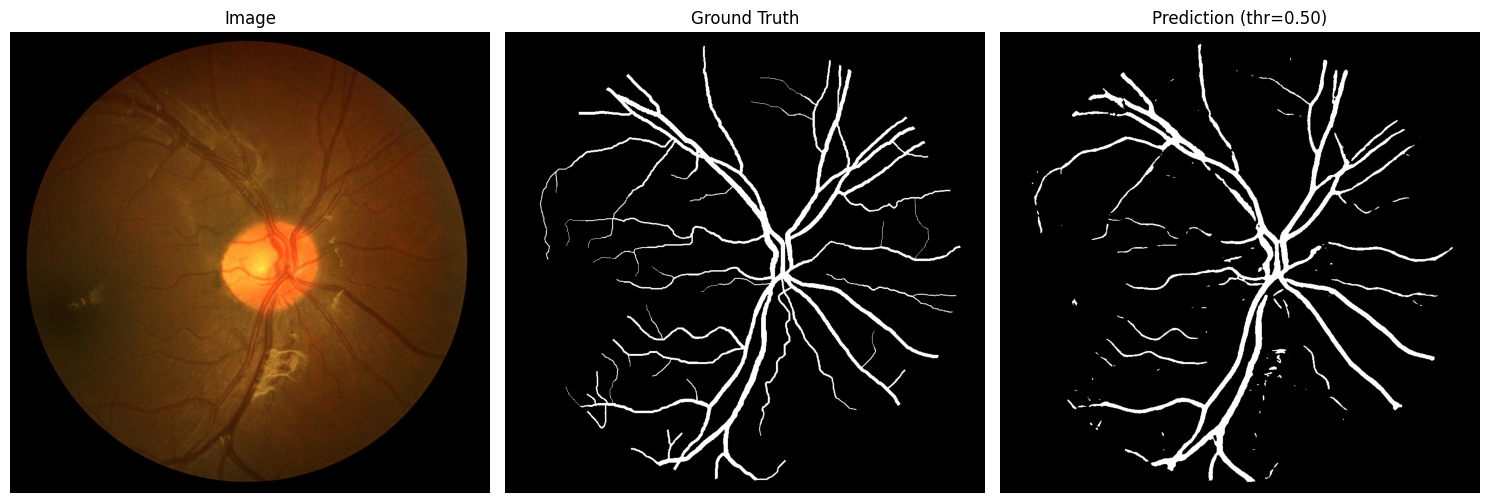

Saved visualization to /workspace/notebook/results/prediction_2.png


: 

In [ ]:
def split_file_names(file_names, seed, train_ratio=0.8):
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(file_names)
    n_train = int(len(shuffled) * train_ratio)
    return shuffled[:n_train].tolist(), shuffled[n_train:].tolist()

# Global Pytorch Settings
device = torch.device("cuda")
torch.manual_seed(SEED)

# In notebooks, __file__ may be unavailable; fallback to current working directory.
_root = os.getcwd()
image_dir = os.path.join(_root, "datasets/chasedb1", "img")
mask_dir = os.path.join(_root, "datasets/chasedb1", "masks")
file_names = sorted(os.path.splitext(f)[0] for f in os.listdir(mask_dir) if f.endswith(".png"))
train_names, test_names = split_file_names(file_names, seed=SEED, train_ratio=TRAIN_RATIO)


# Turn the data into tensors
train_ds = ImageMaskDataset(image_dir, mask_dir, train_names, augment=True, crop_size=CROP_SIZE)
test_ds = ImageMaskDataset(image_dir, mask_dir, test_names, augment=False)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

# We are only testing UNet and BCE
model = UNet(n_channels=3, n_classes=1, bilinear=BILINEAR).to(device)
bce = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training Loop
for epoch in range(1, EPOCHS + 1):
    train_loss, train_dice = run_epoch(
        model,
        train_loader,
        device,
        bce,
        optimizer,
        w_dice=DICE_WEIGHT,
        w_bce=BCE_WEIGHT,
        train=True,
        desc=f"train {epoch}/{EPOCHS}",
    )
    print(f"epoch {epoch}/{EPOCHS}  train_loss={train_loss:.4f}  train_dice={train_dice:.4f}")

# Testing
test_loss, test_dice = run_epoch(
    model,
    test_loader,
    device,
    bce,
    optimizer=None,
    w_dice=DICE_WEIGHT,
    w_bce=BCE_WEIGHT,
    train=False,
    desc="test",
)
print(f"test_loss={test_loss:.4f}  test_dice={test_dice:.4f}")

# Save trained model checkpoint.
models_dir = os.path.join(_root, "models")
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, MODEL_NAME)
torch.save(model.state_dict(), model_path)
print(f"Saved model to {model_path}")

# Display multiple visualizations inline and also save them.
viz_dir = os.path.join(_root, VIZ_SAVE_DIR)
os.makedirs(viz_dir, exist_ok=True)
for i in range(VIZ_COUNT):
    idx = (VIZ_INDEX + i) % len(test_ds)
    save_path = os.path.join(viz_dir, f"{VIZ_PREFIX}_{idx}.png")
    visualize_prediction(
        model=model,
        dataset=test_ds,
        device=device,
        index=idx,
        threshold=VIZ_THRESHOLD,
        save_path=None,  # show inline in notebook output
    )
    visualize_prediction(
        model=model,
        dataset=test_ds,
        device=device,
        index=idx,
        threshold=VIZ_THRESHOLD,
        save_path=save_path,
    )